# Chapter 9 입출력 작업

## 9.1 기본 파이썬 입출력

### 9.1.1 객체를 디스크에 쓰기

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import pickle
import numpy as np
from random import gauss

In [3]:
a = [gauss(1.5, 2) for i in range(1000000)]

In [4]:
path = '/Users/kunyoungkim/workspace/studies/books/python-for-finance/data/'

In [5]:
with open(path + 'data.pkl', 'wb') as pkl_file:
    %time pickle.dump(a, pkl_file)

CPU times: user 5.99 ms, sys: 2.16 ms, total: 8.15 ms
Wall time: 7.82 ms


In [6]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  9003247 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/data.pkl


In [7]:
with open(path + 'data.pkl', 'rb') as pkl_file:
    %time b = pickle.load(pkl_file)

CPU times: user 7.1 ms, sys: 2.97 ms, total: 10.1 ms
Wall time: 9.38 ms


In [8]:
a[:3]

[-0.6969083523977075, 4.943714076427993, 5.041180425530067]

In [9]:
b[:3]

[-0.6969083523977075, 4.943714076427993, 5.041180425530067]

In [10]:
np.allclose(np.array(a), np.array(b))

True

In [11]:
with open(path + 'data.pkl', 'wb') as pkl_file:
    %time pickle.dump(np.array(a), pkl_file)
    %time pickle.dump(np.array(a) ** 2, pkl_file)

CPU times: user 12.7 ms, sys: 1.17 ms, total: 13.9 ms
Wall time: 13.8 ms
CPU times: user 12.5 ms, sys: 1.39 ms, total: 13.9 ms
Wall time: 13.9 ms


In [12]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  16000278 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/data.pkl


In [13]:
with open(path + 'data.pkl', 'rb') as pkl_file:
    x = pickle.load(pkl_file)
    y = pickle.load(pkl_file)

In [14]:
x[:4]

array([-0.69690835,  4.94371408,  5.04118043,  2.44901353])

In [15]:
y[:4]

array([ 0.48568125, 24.44030887, 25.41350008,  5.99766725])

In [16]:
with open(path + 'data.pkl', 'wb') as pkl_file:
    pickle.dump({'x': x, 'y': y}, pkl_file)

In [17]:
with open(path + 'data.pkl', 'rb') as pkl_file:
    data = pickle.load(pkl_file)

In [18]:
for key in data.keys():
    print(key, data[key][:4])

x [-0.69690835  4.94371408  5.04118043  2.44901353]
y [ 0.48568125 24.44030887 25.41350008  5.99766725]


In [19]:
!rm -f $path*

### 9.1.2 텍스트 파일 읽고 쓰기

In [20]:
import pandas as pd

In [21]:
rows = 500
a = np.random.standard_normal((rows, 5)).round(4)

In [22]:
a

array([[ 0.3729,  1.6858,  1.1784,  1.0478, -1.3144],
       [ 0.6361,  0.1548,  0.5342,  0.196 ,  1.5597],
       [-0.4229, -0.1931, -0.0995,  0.2128,  0.9213],
       ...,
       [ 1.3254, -1.9613,  0.0529, -1.2382,  0.6994],
       [ 1.5333, -1.4179, -2.4164, -0.1311,  2.868 ],
       [-1.0335,  1.1148, -0.4383,  0.4907,  0.2594]], shape=(500, 5))

In [23]:
t = pd.date_range(start='2019/1/1', periods=rows, freq='h')

In [24]:
t

DatetimeIndex(['2019-01-01 00:00:00', '2019-01-01 01:00:00',
               '2019-01-01 02:00:00', '2019-01-01 03:00:00',
               '2019-01-01 04:00:00', '2019-01-01 05:00:00',
               '2019-01-01 06:00:00', '2019-01-01 07:00:00',
               '2019-01-01 08:00:00', '2019-01-01 09:00:00',
               ...
               '2019-01-21 10:00:00', '2019-01-21 11:00:00',
               '2019-01-21 12:00:00', '2019-01-21 13:00:00',
               '2019-01-21 14:00:00', '2019-01-21 15:00:00',
               '2019-01-21 16:00:00', '2019-01-21 17:00:00',
               '2019-01-21 18:00:00', '2019-01-21 19:00:00'],
              dtype='datetime64[us]', length=500, freq='h')

In [25]:
with open(path + 'data.csv', 'w') as csv_file:
    header = 'date,no1,no2,no3,no4,no5\n'
    csv_file.write(header)
    for t_, (no1, no2, no3, no4, no5) in zip(t, a):
        s = f'{t_},{no1},{no2},{no3},{no4},{no5}\n'
        csv_file.write(s)

In [26]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  28478 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/data.csv


In [27]:
with open(path + 'data.csv', 'r') as csv_file:
    for i in range(5):
        print(csv_file.readline(), end='')

date,no1,no2,no3,no4,no5
2019-01-01 00:00:00,0.3729,1.6858,1.1784,1.0478,-1.3144
2019-01-01 01:00:00,0.6361,0.1548,0.5342,0.196,1.5597
2019-01-01 02:00:00,-0.4229,-0.1931,-0.0995,0.2128,0.9213
2019-01-01 03:00:00,0.3653,-1.0796,-0.8692,2.4836,-0.7579


In [28]:
with open(path + 'data.csv', 'r') as csv_file:
    content = csv_file.readlines()

In [29]:
content[:5]

['date,no1,no2,no3,no4,no5\n',
 '2019-01-01 00:00:00,0.3729,1.6858,1.1784,1.0478,-1.3144\n',
 '2019-01-01 01:00:00,0.6361,0.1548,0.5342,0.196,1.5597\n',
 '2019-01-01 02:00:00,-0.4229,-0.1931,-0.0995,0.2128,0.9213\n',
 '2019-01-01 03:00:00,0.3653,-1.0796,-0.8692,2.4836,-0.7579\n']

In [30]:
import csv

In [31]:
with open(path + 'data.csv', 'r') as f:
    csv_reader = csv.reader(f)
    lines = [line for line in csv_reader]

In [32]:
lines[:5]

[['date', 'no1', 'no2', 'no3', 'no4', 'no5'],
 ['2019-01-01 00:00:00', '0.3729', '1.6858', '1.1784', '1.0478', '-1.3144'],
 ['2019-01-01 01:00:00', '0.6361', '0.1548', '0.5342', '0.196', '1.5597'],
 ['2019-01-01 02:00:00', '-0.4229', '-0.1931', '-0.0995', '0.2128', '0.9213'],
 ['2019-01-01 03:00:00', '0.3653', '-1.0796', '-0.8692', '2.4836', '-0.7579']]

In [33]:
with open(path + 'data.csv', 'r') as f:
    csv_reader = csv.DictReader(f)
    lines = [line for line in csv_reader]

In [34]:
lines[:5]

[{'date': '2019-01-01 00:00:00',
  'no1': '0.3729',
  'no2': '1.6858',
  'no3': '1.1784',
  'no4': '1.0478',
  'no5': '-1.3144'},
 {'date': '2019-01-01 01:00:00',
  'no1': '0.6361',
  'no2': '0.1548',
  'no3': '0.5342',
  'no4': '0.196',
  'no5': '1.5597'},
 {'date': '2019-01-01 02:00:00',
  'no1': '-0.4229',
  'no2': '-0.1931',
  'no3': '-0.0995',
  'no4': '0.2128',
  'no5': '0.9213'},
 {'date': '2019-01-01 03:00:00',
  'no1': '0.3653',
  'no2': '-1.0796',
  'no3': '-0.8692',
  'no4': '2.4836',
  'no5': '-0.7579'},
 {'date': '2019-01-01 04:00:00',
  'no1': '0.4804',
  'no2': '-0.4212',
  'no3': '0.1102',
  'no4': '-2.309',
  'no5': '1.748'}]

In [35]:
!rm -f $path*

### 9.1.3 SQL 데이터베이스 작업

In [36]:
import sqlite3 as sq3

In [37]:
con = sq3.connect(path + 'numbs.db')

In [38]:
query = 'CREATE TABLE numbs (Date date, No1 real, No2 real)'

In [39]:
con.execute(query)

In [40]:
con.commit()

In [41]:
q = con.execute

In [42]:
q('SELECT * FROM sqlite_master').fetchall()

[('table',
  'numbs',
  'numbs',
  2,
  'CREATE TABLE numbs (Date date, No1 real, No2 real)')]

In [43]:
import datetime

In [44]:
now = datetime.datetime.now()

In [45]:
q('INSERT INTO numbs VALUES(?, ?, ?)', (now.isoformat(), 0.12, 7.3))

In [46]:
np.random.seed(100)

In [47]:
data = np.random.standard_normal((10000, 2)).round(4)

In [48]:
%%time
for row in data:
    now = datetime.datetime.now()
    q('INSERT INTO numbs VALUES(?, ?, ?)', (now.isoformat(), row[0], row[1]))
con.commit()

CPU times: user 16.5 ms, sys: 1.94 ms, total: 18.4 ms
Wall time: 18.7 ms


In [49]:
q('SELECT * FROM numbs').fetchmany(4)

[('2026-07-06T22:25:29.048717', 0.12, 7.3),
 ('2026-07-06T22:25:29.064120', -1.7498, 0.3427),
 ('2026-07-06T22:25:29.064154', 1.153, -0.2524),
 ('2026-07-06T22:25:29.064329', 0.9813, 0.5142)]

In [50]:
q('SELECT * FROM numbs WHERE no1 > 0.5').fetchmany(4)

[('2026-07-06T22:25:29.064154', 1.153, -0.2524),
 ('2026-07-06T22:25:29.064329', 0.9813, 0.5142),
 ('2026-07-06T22:25:29.064354', 0.6727, -0.1044),
 ('2026-07-06T22:25:29.064362', 1.619, 1.5416)]

In [51]:
pointer = q('SELECT * FROM numbs')

In [52]:
for i in range(3):
    print(pointer.fetchone())

('2026-07-06T22:25:29.048717', 0.12, 7.3)
('2026-07-06T22:25:29.064120', -1.7498, 0.3427)
('2026-07-06T22:25:29.064154', 1.153, -0.2524)


In [53]:
rows = pointer.fetchall()
rows[:3]

[('2026-07-06T22:25:29.064329', 0.9813, 0.5142),
 ('2026-07-06T22:25:29.064335', 0.2212, -1.07),
 ('2026-07-06T22:25:29.064339', -0.1895, 0.255)]

In [54]:
q('DROP TABLE IF EXISTS numbs')

In [55]:
q('SELECT * FROM sqlite_master').fetchall()

[]

In [56]:
con.close()

In [57]:
!rm -f $path*

### 9.1.4 Numpy 배열 읽고 쓰기

In [58]:
dtimes = np.arange('2019-01-01 10:00:00', '2025-12-31 22:00:00', dtype='datetime64[m]')

In [59]:
len(dtimes)

3681360

In [60]:
dty = np.dtype([('Date', 'datetime64[m]'), ('No1', 'f'), ('No2', 'f')])

In [61]:
data = np.zeros(len(dtimes), dtype=dty)

In [62]:
data['Date'] = dtimes

In [63]:
a = np.random.standard_normal((len(dtimes), 2)).round(4)

In [64]:
data['No1'] = a[:,0]
data['No2'] = a[:,1]

In [65]:
data.nbytes

58901760

In [66]:
%time np.save(path + 'array', data)

CPU times: user 263 μs, sys: 4.65 ms, total: 4.91 ms
Wall time: 4.54 ms


In [67]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  58901952 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/array.npy


In [68]:
%time np.load(path + 'array.npy')

CPU times: user 443 μs, sys: 9.12 ms, total: 9.56 ms
Wall time: 8.74 ms


array([('2019-01-01T10:00',  1.5131,  0.6973),
       ('2019-01-01T10:01', -1.722 , -0.4815),
       ('2019-01-01T10:02',  0.8251,  0.3019), ...,
       ('2025-12-31T21:57',  1.372 ,  0.6446),
       ('2025-12-31T21:58', -1.2542,  0.1612),
       ('2025-12-31T21:59', -1.1997, -1.097 )],
      shape=(3681360,), dtype=[('Date', '<M8[m]'), ('No1', '<f4'), ('No2', '<f4')])

In [69]:
%time data = np.random.standard_normal((10000, 6000)).round(4)

CPU times: user 507 ms, sys: 51 ms, total: 558 ms
Wall time: 558 ms


In [70]:
data.nbytes

480000000

In [71]:
%time np.save(path + 'array', data)

CPU times: user 428 μs, sys: 42 ms, total: 42.4 ms
Wall time: 41.2 ms


In [72]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  480000128 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/array.npy


In [73]:
%time np.load(path + 'array.npy')

CPU times: user 473 μs, sys: 55.8 ms, total: 56.3 ms
Wall time: 55.4 ms


array([[ 0.3066,  0.5951,  0.5826, ...,  1.6773,  0.4294, -0.2216],
       [ 0.8769,  0.7292, -0.9557, ...,  0.5084,  0.9635, -0.4443],
       [-1.2202, -2.5509, -0.0575, ..., -1.6128,  0.4662, -1.3645],
       ...,
       [-0.5598,  0.2393, -2.3716, ...,  1.7669,  0.2462,  1.035 ],
       [ 0.273 ,  0.8216, -0.0749, ..., -0.0552, -0.8396,  0.3077],
       [-0.6305,  0.8331,  1.3702, ...,  0.3493,  0.1981,  0.2037]],
      shape=(10000, 6000))

In [74]:
!rm -f $path*

## 9.2 pandas를 이용한 입출력

In [75]:
data = np.random.standard_normal((1000000, 5)).round(4)

In [76]:
data[:3]

array([[ 0.4918,  1.3707,  0.137 ,  0.3981, -1.0059],
       [ 0.4516,  1.4445,  0.0555, -0.0397,  0.44  ],
       [ 0.1629, -0.8473, -0.8223, -0.4621, -0.5137]])

### 9.2.1 SQL 데이터베이스 작업

In [77]:
filename = path + 'numbers'

In [78]:
con = sq3.connect(filename + '.db')

In [79]:
query = 'CREATE TABLE numbers (No1 real, No2 real, No3 real, No4 real, No5 real)'

In [80]:
q = con.execute
qm = con.executemany

In [81]:
q(query)

In [82]:
%%time
qm('INSERT INTO numbers VALUES (?, ?, ?, ?, ?)', data)
con.commit()

CPU times: user 448 ms, sys: 40.4 ms, total: 489 ms
Wall time: 490 ms


In [83]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  52633600 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/numbers.db


In [84]:
%%time
temp = q('SELECT * FROM numbers').fetchall()
print(temp[:3])

[(0.4918, 1.3707, 0.137, 0.3981, -1.0059), (0.4516, 1.4445, 0.0555, -0.0397, 0.44), (0.1629, -0.8473, -0.8223, -0.4621, -0.5137)]
CPU times: user 285 ms, sys: 24 ms, total: 310 ms
Wall time: 309 ms


In [85]:
%%time
query = 'SELECT * FROM numbers WHERE No1 > 0 AND No2 < 0'
res = np.array(q(query).fetchall()).round(3)

CPU times: user 134 ms, sys: 13.1 ms, total: 147 ms
Wall time: 147 ms


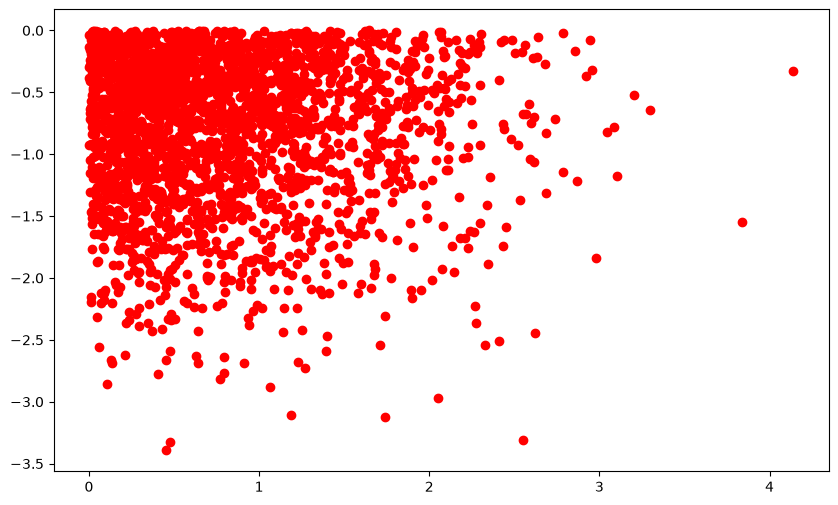

In [86]:
res = res[::100]
plt.figure(figsize=(10,6))
plt.plot(res[:,0], res[:,1], 'ro')
plt.show()

### 9.2.2 SQL에서 pandas로

In [87]:
%time data = pd.read_sql('SELECT * FROM numbers', con)

CPU times: user 388 ms, sys: 36.1 ms, total: 424 ms
Wall time: 423 ms


In [88]:
data.head()

,No1,No2,No3,No4,No5
0,0.4918,1.3707,0.1370,0.3981,-1.0059
1,0.4516,1.4445,0.0555,-0.0397,0.4400
2,0.1629,-0.8473,-0.8223,-0.4621,-0.5137
3,1.3064,0.9125,0.5142,-0.7868,-0.3398
4,-0.1148,-1.5215,-0.7045,-1.0042,-0.0600


In [89]:
%time data[(data['No1'] > 0) & (data['No2'] < 0)].head()

CPU times: user 3.42 ms, sys: 2.84 ms, total: 6.26 ms
Wall time: 5.63 ms


,No1,No2,No3,No4,No5
2,0.1629,-0.8473,-0.8223,-0.4621,-0.5137
5,0.1893,-0.0207,-0.2104,0.9419,0.2551
8,1.4784,-0.3333,-0.7050,0.3586,-0.3937
10,0.8092,-0.9899,1.0364,-1.0453,0.0579
11,0.9065,-0.7757,-0.9267,0.7797,0.0863


In [90]:
%%time
q = '(No1 < -0.5 | No1 > 0.5) & (No2 < -0.5 | No2 > 0.5)'
res = data[['No1', 'No2']].query(q)

CPU times: user 11.9 ms, sys: 4.83 ms, total: 16.8 ms
Wall time: 7.46 ms


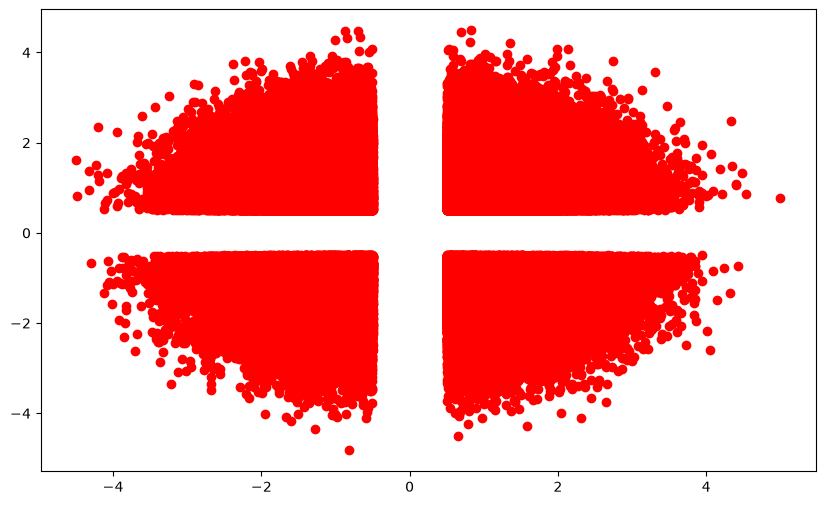

In [91]:
plt.figure(figsize=(10,6))
plt.plot(res['No1'], res['No2'], 'ro')
plt.show()

In [92]:
h5s = pd.HDFStore(filename + '.h5s', 'w')

In [93]:
%time h5s['data'] = data

CPU times: user 7.88 ms, sys: 7.4 ms, total: 15.3 ms
Wall time: 14.7 ms


In [94]:
h5s

<class 'pandas.HDFStore'>
File path: /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/numbers.h5s

In [95]:
h5s.close()

In [96]:
%%time
h5s = pd.HDFStore(filename + '.h5s', 'r')
data_ = h5s['data']
h5s.close()

CPU times: user 5.46 ms, sys: 6.16 ms, total: 11.6 ms
Wall time: 11.2 ms


In [97]:
data_ is data

False

In [98]:
(data_ == data).all()

No1    True
No2    True
No3    True
No4    True
No5    True
dtype: bool

In [99]:
np.allclose(data_, data)

True

In [100]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  52633600 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/numbers.db
-rw-r--r--@ 1 kunyoungkim  staff  48007168 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/numbers.h5s


### 9.2.3 CSV 파일 작업

In [101]:
%time data.to_csv(filename + '.csv')

CPU times: user 1.18 s, sys: 22.1 ms, total: 1.2 s
Wall time: 1.21 s


In [102]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  43834157 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/numbers.csv
-rw-r--r--@ 1 kunyoungkim  staff  52633600 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/numbers.db
-rw-r--r--@ 1 kunyoungkim  staff  48007168 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/numbers.h5s


In [103]:
%time df = pd.read_csv(filename + '.csv')

CPU times: user 142 ms, sys: 12.8 ms, total: 155 ms
Wall time: 154 ms


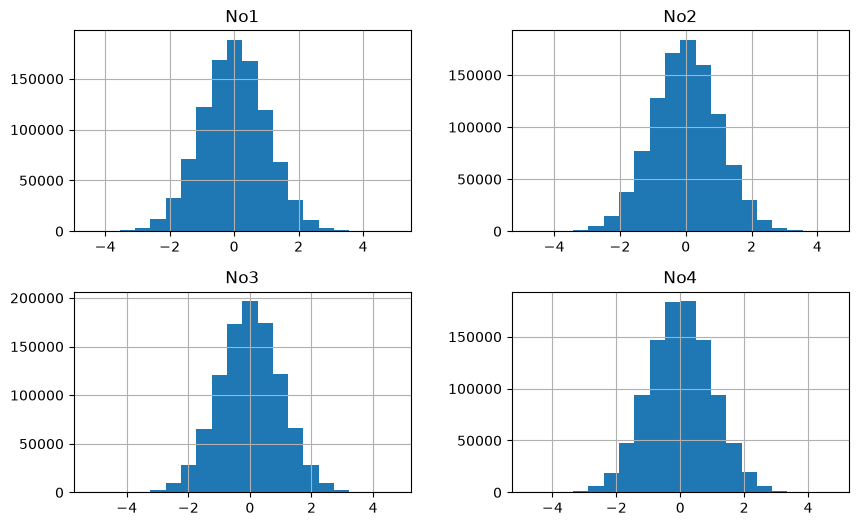

In [104]:
df[['No1', 'No2', 'No3', 'No4']].hist(bins=20, figsize=(10,6))
plt.show()

### 9.2.4 엑셀 파일 작업

In [105]:
%time data[:100000].to_excel(filename + '.xlsx')

CPU times: user 2.43 s, sys: 39.6 ms, total: 2.46 s
Wall time: 2.49 s


In [106]:
%time df = pd.read_excel(filename + '.xlsx', 'Sheet1')

CPU times: user 1.33 s, sys: 11.8 ms, total: 1.34 s
Wall time: 1.34 s


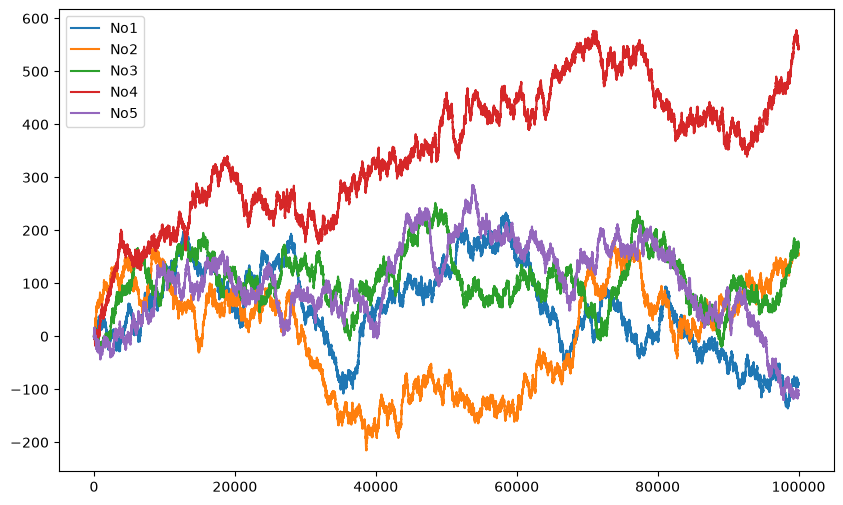

In [107]:
df[['No1', 'No2', 'No3', 'No4', 'No5']].cumsum().plot(figsize=(10,6))
plt.show()

In [108]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  43834157 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/numbers.csv
-rw-r--r--@ 1 kunyoungkim  staff  52633600 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/numbers.db
-rw-r--r--@ 1 kunyoungkim  staff  48007168 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/numbers.h5s
-rw-r--r--@ 1 kunyoungkim  staff   3950083 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/numbers.xlsx


In [109]:
rm -f $path*

## 9.3 PyTables를 이용한 입출력

In [110]:
import tables as tb
import datetime as dt

### 9.3.1 테이블 작업

In [111]:
filename = path + 'pytab.h5'

In [112]:
h5 = tb.open_file(filename, 'w')

In [113]:
row_des = {
    'Date': tb.StringCol(26, pos=1),
    'No1': tb.IntCol(pos=2),
    'No2': tb.IntCol(pos=3),
    'No3': tb.Float64Col(pos=4),
    'No4': tb.Float64Col(pos=5)
}

In [114]:
rows = 2000000

In [115]:
filters = tb.Filters(complevel=0)

In [116]:
tab = h5.create_table('/', 'ints_floats',
                      row_des,
                      title='Integers and Floats',
                      expectedrows=rows,
                      filters=filters)

In [117]:
type(tab)

tables.table.Table

In [118]:
tab

/ints_floats (Table(np.int64(0),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape := (np.int64(2621),)

In [119]:
pointer = tab.row

In [120]:
ran_int = np.random.randint(0, 10000, size=(rows,2))

In [121]:
ran_flo = np.random.standard_normal((rows, 2)).round(4)

In [122]:
%%time
for i in range(rows):
    pointer['Date'] = dt.datetime.now()
    pointer['No1'] = ran_int[i, 0]
    pointer['No2'] = ran_int[i, 1]
    pointer['No3'] = ran_flo[i, 0]
    pointer['No4'] = ran_flo[i, 1]
    pointer.append()
tab.flush()

CPU times: user 1.82 s, sys: 22.8 ms, total: 1.85 s
Wall time: 1.85 s


In [123]:
tab

/ints_floats (Table(np.int64(2000000),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape := (np.int64(2621),)

In [124]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  100157388 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/pytab.h5


In [125]:
dty = np.dtype([('Date', 'S26'), ('No1', '<i4'), ('No2', '<i4'), ('No3', '<f8'), ('No4', '<f8')]) 

In [126]:
sarray = np.zeros(len(ran_int), dtype=dty)

In [127]:
sarray[:4]

array([(b'', 0, 0, 0., 0.), (b'', 0, 0, 0., 0.), (b'', 0, 0, 0., 0.),
       (b'', 0, 0, 0., 0.)],
      dtype=[('Date', 'S26'), ('No1', '<i4'), ('No2', '<i4'), ('No3', '<f8'), ('No4', '<f8')])

In [128]:
%%time
sarray['Date'] = dt.datetime.now()
sarray['No1'] = ran_int[:, 0]
sarray['No2'] = ran_int[:, 1]
sarray['No3'] = ran_flo[:, 0]
sarray['No4'] = ran_flo[:, 1]

CPU times: user 14.5 ms, sys: 4.32 ms, total: 18.8 ms
Wall time: 18.1 ms


In [129]:
%%time
h5.create_table('/', 'ints_floats_from_array', sarray,
                title='Integers and Floats', 
                expectedrows=rows, filters=filters)

CPU times: user 4.31 ms, sys: 6.69 ms, total: 11 ms
Wall time: 11 ms


/ints_floats_from_array (Table(np.int64(2000000),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape := (np.int64(2621),)

In [130]:
type(h5)

tables.file.File

In [131]:
h5

File(filename=/Users/kunyoungkim/workspace/studies/books/python-for-finance/data/pytab.h5, title=np.str_(''), mode='w', root_uep='/', filters=Filters(complevel=0, shuffle=False, bitshuffle=False, fletcher32=False, least_significant_digit=None))
/ (RootGroup) np.str_('')
/ints_floats (Table(np.int64(2000000),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), pos=4)}
  byteorder := 'little'
  chunkshape := (np.int64(2621),)
/ints_floats_from_array (Table(np.int64(2000000),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2)

In [132]:
h5.remove_node('/', 'ints_floats_from_array')

In [133]:
tab[:3]

array([(b'2026-07-06 22:25:39.264370', 8576, 5991, -0.0528, 0.2468),
       (b'2026-07-06 22:25:39.264422', 2990, 9310, -0.0261, 0.3932),
       (b'2026-07-06 22:25:39.264425', 4400, 4823,  0.9133, 0.2579)],
      dtype=[('Date', 'S26'), ('No1', '<i4'), ('No2', '<i4'), ('No3', '<f8'), ('No4', '<f8')])

In [134]:
tab[:4]['No4']

array([ 0.2468,  0.3932,  0.2579, -0.5582])

In [135]:
%time np.sum(tab[:]['No3'])

CPU times: user 5.39 ms, sys: 10.7 ms, total: 16.1 ms
Wall time: 15.7 ms


np.float64(88.8542999999997)

In [136]:
%time np.sum(np.sqrt(tab[:]['No1']))

CPU times: user 6.05 ms, sys: 10.1 ms, total: 16.1 ms
Wall time: 15.4 ms


np.float64(133349920.36892518)

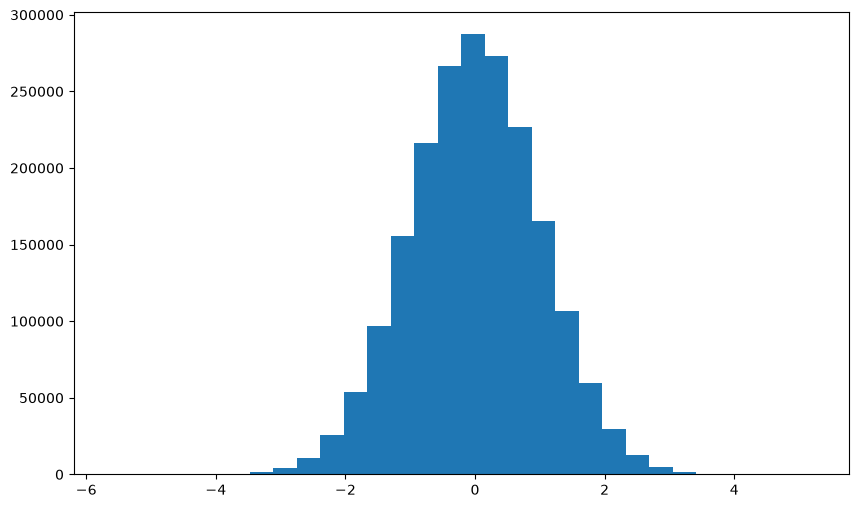

CPU times: user 41.3 ms, sys: 14.5 ms, total: 55.9 ms
Wall time: 55.4 ms


In [137]:
%%time
plt.figure(figsize=(10,6))
plt.hist(tab[:]['No3'], bins=30)
plt.show()

In [138]:
query = '((No3 < -0.5) | (No3 > 0.5)) & ((No4 < -1) | (No4 > 1))'

In [139]:
iterator = tab.where(query)

In [140]:
%time res = [(row['No3'], row['No4']) for row in iterator]

CPU times: user 47 ms, sys: 20.3 ms, total: 67.3 ms
Wall time: 40.5 ms


In [141]:
res = np.array(res)
res[:3]

array([[0.7694, 1.4866],
       [0.9201, 1.3346],
       [1.4701, 1.8776]])

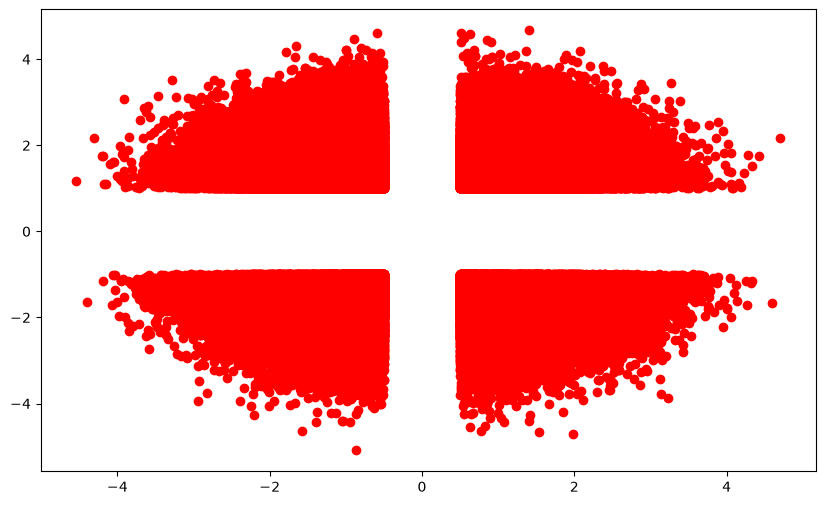

In [142]:
plt.figure(figsize=(10,6))
plt.plot(res.T[0], res.T[1], 'ro');
plt.show()

In [143]:
%%time
values = tab[:]['No3']
print('Max %18.3f' % values.max())
print('Ave %18.3f' % values.mean())
print('Min %18.3f' % values.min())
print('Std %18.3f' % values.std())

Max              5.224
Ave              0.000
Min             -5.649
Std              1.000
CPU times: user 13.1 ms, sys: 12.1 ms, total: 25.2 ms
Wall time: 24.8 ms


In [144]:
%%time
res = [(row['No1'], row['No2']) for row in tab.where('((No1 > 9800) | (No1 < 200)) & ((No2 > 4500) | (No2 < 5500))')]

CPU times: user 30.6 ms, sys: 13.8 ms, total: 44.4 ms
Wall time: 24.6 ms


In [145]:
for r in res[:4]:
    print(r)

(84, 9274)
(9919, 9847)
(9904, 8917)
(9956, 7434)


In [146]:
%%time
res = [(row['No1'], row['No2']) for row in tab.where('(No1 == 1234) & (No2 > 9776)')]

CPU times: user 13 ms, sys: 12.9 ms, total: 25.9 ms
Wall time: 12.9 ms


In [147]:
for r in res:
    print(r)

(1234, 9841)
(1234, 9821)
(1234, 9867)
(1234, 9987)
(1234, 9849)
(1234, 9800)


### 9.3.2 압축 테이블 작업

In [148]:
filename = path + 'pytabc.h5'

In [149]:
h5c = tb.open_file(filename, 'w')

In [150]:
filters = tb.Filters(complevel=5,
                     complib='blosc')

In [151]:
tabc = h5c.create_table('/', 'ints_floats', sarray,
                        title='Integers and Floats',
                        expectedrows=rows, filters=filters)

In [152]:
query = '((No3 < -0.5) | (No3 > 0.5)) & ((No4 < -1) | (No4 > 1))'

In [153]:
%time res = [(row['No3'], row['No4']) for row in tabc.where(query)]

CPU times: user 51.4 ms, sys: 20 ms, total: 71.3 ms
Wall time: 47.1 ms


In [154]:
res = np.array(res)
res[:3]

array([[0.7694, 1.4866],
       [0.9201, 1.3346],
       [1.4701, 1.8776]])

In [155]:
%time arr_non = tab.read()

CPU times: user 3.79 ms, sys: 8.91 ms, total: 12.7 ms
Wall time: 12 ms


In [156]:
tab.size_on_disk

100122200

In [157]:
arr_non.nbytes

100000000

In [158]:
%time arr_com = tabc.read()

CPU times: user 3.82 ms, sys: 10.9 ms, total: 14.8 ms
Wall time: 14.2 ms


In [159]:
tabc.size_on_disk

99995409

In [160]:
arr_com.nbytes

100000000

In [161]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  200312336 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/pytab.h5
-rw-r--r--@ 1 kunyoungkim  staff  100029517 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/pytabc.h5


In [162]:
h5c.close()

### 9.3.3 배열 작업

In [163]:
%%time
arr_int = h5.create_array('/', 'integers', ran_int)
arr_flo = h5.create_array('/', 'floats', ran_flo)

CPU times: user 510 μs, sys: 3.66 ms, total: 4.17 ms
Wall time: 4.18 ms


In [164]:
h5

File(filename=/Users/kunyoungkim/workspace/studies/books/python-for-finance/data/pytab.h5, title=np.str_(''), mode='w', root_uep='/', filters=Filters(complevel=0, shuffle=False, bitshuffle=False, fletcher32=False, least_significant_digit=None))
/ (RootGroup) np.str_('')
/floats (Array(2000000, 2)) np.str_('')
  atom := Float64Atom(shape=(), dflt=np.float64(0.0))
  maindim := 0
  flavor := 'numpy'
  byteorder := 'little'
  chunkshape := None
/integers (Array(2000000, 2)) np.str_('')
  atom := Int64Atom(shape=(), dflt=np.int64(0))
  maindim := 0
  flavor := 'numpy'
  byteorder := 'little'
  chunkshape := None
/ints_floats (Table(np.int64(2000000),)) np.str_('Integers and Floats')
  description := {
  "Date": StringCol(itemsize=26, shape=(), dflt=np.bytes_(b''), pos=0),
  "No1": Int32Col(shape=(), dflt=np.int32(0), pos=1),
  "No2": Int32Col(shape=(), dflt=np.int32(0), pos=2),
  "No3": Float64Col(shape=(), dflt=np.float64(0.0), pos=3),
  "No4": Float64Col(shape=(), dflt=np.float64(0.0), po

In [165]:
ll $path*

-rw-r--r--@ 1 kunyoungkim  staff  262344490 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/pytab.h5
-rw-r--r--@ 1 kunyoungkim  staff  100030541 Jul  6 22:25 /Users/kunyoungkim/workspace/studies/books/python-for-finance/data/pytabc.h5


In [166]:
h5.close()

In [167]:
!rm -f $path*

### 9.3.4 out-of-memory 연산

In [168]:
filename = path + 'earray.h5'

In [169]:
h5 = tb.open_file(filename, 'w')

In [170]:
n = 500

In [171]:
ear = h5.create_earray('/', 'ear',
                       atom=tb.Float64Atom(),
                       shape=(0,n))

In [172]:
type(ear)

tables.earray.EArray

In [173]:
rand = np.random.standard_normal((n, n))
rand[:4, :4]

array([[-1.25983231,  1.11420699,  0.1667485 ,  0.7345676 ],
       [-0.13785424,  1.22232417,  1.36303097,  0.13521042],
       [ 1.45487119, -1.47784078,  0.15027672,  0.86755989],
       [-0.63519366,  0.1516327 , -0.64939447, -0.45010975]])

In [174]:
%%time
for _ in range(750):
    ear.append(rand)
ear.flush()

CPU times: user 68 ms, sys: 177 ms, total: 245 ms
Wall time: 245 ms


In [175]:
ear

/ear (EArray(np.int64(375000), np.int64(500))) ''
  atom := Float64Atom(shape=(), dflt=np.float64(0.0))
  maindim := 0
  flavor := 'numpy'
  byteorder := 'little'
  chunkshape := (np.int64(16), np.int64(500))

In [176]:
ear.size_on_disk

1500032000

In [177]:
out = h5.create_earray('/', 'out', 
                       atom=tb.Float64Atom(),
                       shape=(0,n))

In [178]:
out.size_on_disk

0

In [179]:
expr = tb.Expr('3 * sin(ear) + sqrt(abs(ear))')

In [180]:
expr.set_output(out, append_mode=True)

In [181]:
%time expr.eval()

CPU times: user 1.36 s, sys: 449 ms, total: 1.81 s
Wall time: 516 ms


/out (EArray(np.int64(375000), np.int64(500))) ''
  atom := Float64Atom(shape=(), dflt=np.float64(0.0))
  maindim := 0
  flavor := 'numpy'
  byteorder := 'little'
  chunkshape := (np.int64(16), np.int64(500))

In [182]:
out.size_on_disk

1500032000

In [183]:
out[0, :10]

array([-1.73369462,  3.74824436,  0.90627898,  2.86786818,  1.75424957,
       -0.91108973, -1.68313885,  1.29073295, -1.68665599, -1.71345309])

In [184]:
%time out_ = out.read()

CPU times: user 71.8 ms, sys: 153 ms, total: 224 ms
Wall time: 224 ms


In [185]:
out_[0, :10]

array([-1.73369462,  3.74824436,  0.90627898,  2.86786818,  1.75424957,
       -0.91108973, -1.68313885,  1.29073295, -1.68665599, -1.71345309])

In [186]:
import numexpr as ne

In [187]:
expr = '3 * sin(out_) + sqrt(abs(out_))'

In [188]:
ne.set_num_threads(1)

16

In [189]:
%time ne.evaluate(expr)[0, :10]

CPU times: user 1.08 s, sys: 60 ms, total: 1.14 s
Wall time: 1.14 s


array([-1.64358578,  0.22567882,  3.31363043,  2.50443549,  4.27413965,
       -1.41600606, -1.68373023,  4.01921805, -1.68117412, -1.66053597])

In [190]:
ne.set_num_threads(4)

1

In [191]:
%time ne.evaluate(expr)[0, :10]

CPU times: user 1.15 s, sys: 89.2 ms, total: 1.24 s
Wall time: 311 ms


array([-1.64358578,  0.22567882,  3.31363043,  2.50443549,  4.27413965,
       -1.41600606, -1.68373023,  4.01921805, -1.68117412, -1.66053597])

In [192]:
h5.close()

In [193]:
!rm -f $path*

## 9.4 TsTables을 이용한 입출력

### 9.4.1 예제 데이터

In [194]:
no = 5000000
co = 3
interval = 1. / (12 * 30 * 24 * 60)
vol = 0.2

In [195]:
%%time
rn = np.random.standard_normal((no, co))
rn[0] = 0.0
paths = 100 * np.exp(np.cumsum(-0.5 * vol ** 2 * interval + vol * np.sqrt(interval) * rn, axis=0))
paths[0] = 100

CPU times: user 196 ms, sys: 27.5 ms, total: 224 ms
Wall time: 223 ms


In [196]:
dr = pd.date_range('2019-1-1', periods=no, freq='1s')

In [197]:
dr[-6:]

DatetimeIndex(['2019-02-27 20:53:14', '2019-02-27 20:53:15',
               '2019-02-27 20:53:16', '2019-02-27 20:53:17',
               '2019-02-27 20:53:18', '2019-02-27 20:53:19'],
              dtype='datetime64[us]', freq='s')

In [198]:
df = pd.DataFrame(paths, index=dr, columns=['ts1', 'ts2', 'ts3'])

In [199]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5000000 entries, 2019-01-01 00:00:00 to 2019-02-27 20:53:19
Freq: s
Data columns (total 3 columns):
 #   Column  Dtype  
---  ------  -----  
 0   ts1     float64
 1   ts2     float64
 2   ts3     float64
dtypes: float64(3)
memory usage: 152.6 MB


In [200]:
df.head()

,ts1,ts2,ts3
2019-01-01 00:00:00,100.000000,100.000000,100.000000
2019-01-01 00:00:01,100.018443,99.966644,99.998255
2019-01-01 00:00:02,100.069023,100.004420,99.986646
2019-01-01 00:00:03,100.086757,100.000246,99.992042
2019-01-01 00:00:04,100.105448,100.036033,99.950618


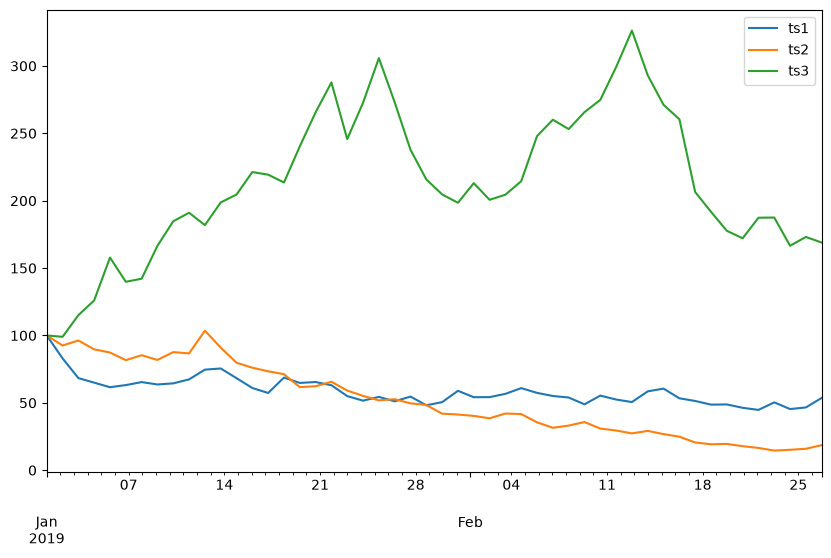

In [201]:
df[::100000].plot(figsize=(10,6))
plt.show()

### 9.4.2 데이터 저장

In [202]:
dty = np.dtype([('timestamp', '<i8'), ('ts1', '<f8'), ('ts2', '<f8'), ('ts3', '<f8')])

In [203]:
ts_array = np.zeros(len(df), dtype=dty)

In [204]:
%%time
ts_array['timestamp'] = df.index
ts_array['ts1'] = df['ts1'].to_numpy()
ts_array['ts2'] = df['ts2'].to_numpy()
ts_array['ts3'] = df['ts3'].to_numpy()

CPU times: user 14.9 ms, sys: 9.03 ms, total: 24 ms
Wall time: 23.6 ms


In [205]:
h5 = tb.open_file(path + 'tstab.h5', 'w')

In [206]:
%%time
ts = h5.create_table('/', 'ts', ts_array)
ts.flush()

CPU times: user 5.72 ms, sys: 14.6 ms, total: 20.4 ms
Wall time: 20.4 ms


In [207]:
type(ts)

tables.table.Table

In [208]:
ls -n $path

total 312896
-rw-r--r--@ 1 501  20  160199843 Jul  6 22:25 tstab.h5


### 9.4.3 데이터 읽기

In [209]:
pd.to_datetime(ts.read()['timestamp'].min())

Timestamp('1970-01-18 21:31:40.800000')

In [210]:
read_start_dt = pd.Timestamp(2019, 2, 1, 0, 0).value // 1000
read_end_dt = pd.Timestamp(2019, 2, 5, 23, 59).value // 1000

In [211]:
%%time
rows = pd.DataFrame.from_records(
    ts.read_where(
        f'(timestamp >= {read_start_dt}) & '
        f'(timestamp < {read_end_dt})'
    ),
    index='timestamp'
)

rows.index = pd.to_datetime(rows.index)
rows.index.name = None

CPU times: user 114 ms, sys: 16.8 ms, total: 131 ms
Wall time: 125 ms


In [212]:
rows.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 431940 entries, 1970-01-18 22:16:19.200000 to 1970-01-18 22:23:31.139000
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ts1     431940 non-null  float64
 1   ts2     431940 non-null  float64
 2   ts3     431940 non-null  float64
dtypes: float64(3)
memory usage: 13.2 MB


In [213]:
rows.head()

,ts1,ts2,ts3
1970-01-18 22:16:19.200,52.063640,40.474580,217.324713
1970-01-18 22:16:19.201,52.087455,40.471911,217.250070
1970-01-18 22:16:19.202,52.084808,40.458013,217.228712
1970-01-18 22:16:19.203,52.073536,40.451408,217.302912
1970-01-18 22:16:19.204,52.056133,40.450951,217.207481


In [214]:
h5.close()

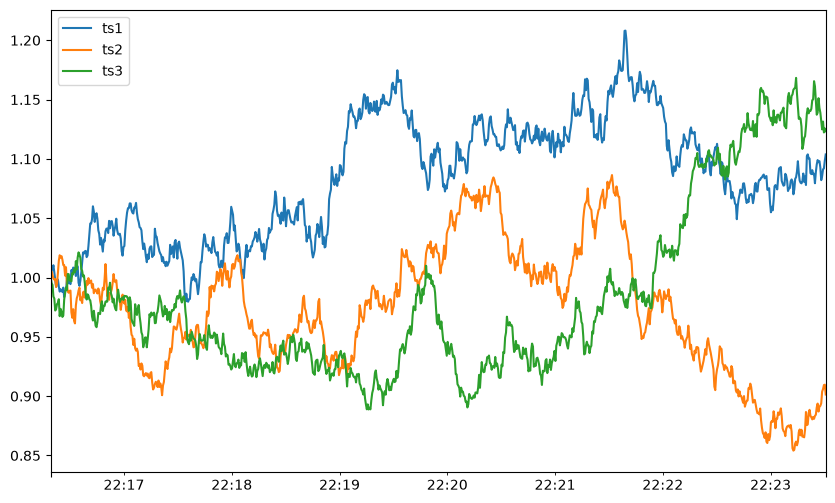

In [215]:
(rows[::500] / rows.iloc[0]).plot(figsize=(10, 6))
plt.show()

In [216]:
import random

In [217]:
h5 = tb.open_file(path + 'tstab.h5', 'r')

In [218]:
ts = h5.root.ts

In [219]:
%%time
for _ in range(100):
    d = random.randint(1, 24)
    read_start_dt = pd.Timestamp(2019, 2, d, 0, 0, 0).value
    read_end_dt = pd.Timestamp(2019, 2, d + 3, 23, 59, 59).value
    rows = pd.DataFrame.from_records(
        ts.read_where(
            f'(timestamp >= {read_start_dt}) & (timestamp < {read_end_dt})'),
        index='timestamp'
    )
    rows.index = pd.to_datetime(rows.index)
    rows.index.name = None

CPU times: user 940 ms, sys: 899 ms, total: 1.84 s
Wall time: 1.38 s


In [220]:
rows.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 0 entries
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ts1     0 non-null      float64
 1   ts2     0 non-null      float64
 2   ts3     0 non-null      float64
dtypes: float64(3)
memory usage: 0.0 bytes


In [221]:
!rm $path*